<div style="background:#12355b;color:white;padding:18px 48px;border-left:6px solid #F48024;font-family:'Segoe UI',sans-serif;border-radius:4px;">
    <p style="color:rgba(255,255,255,0.55);font-size:0.78em;margin:0 0 6px 0;letter-spacing:2px;text-transform:uppercase;">
        Machine Learning &mdash; Bài toán 2 &nbsp;|&nbsp; Stack Overflow Developer Survey 2025
    </p>
    <h1 style="color:#ffffff;font-size:1.6em;margin:0 0 4px 0;font-weight:700;">ML_02: Phân Loại Thái Độ Với AI</h1>
    <p style="color:#F48024;font-size:0.95em;margin:0;">Favorable vs Unfavorable &nbsp;&mdash;&nbsp; Binary Classification</p>
</div>

**Mục tiêu:** Dựa vào đặc điểm cá nhân và hành vi sử dụng AI, phân loại lập trình viên có thái độ Tích cực (Favorable) hay Tiêu cực (Unfavorable) với AI.

**Ứng dụng:** Hiểu profile của các nhóm developer, xác định rào cản triển khai AI trong tổ chức.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve
import xgboost as xgb
import shap

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

DATA_PATH = '../../data/processed/'

### **1. Load Data & Create Binary Target**
Chúng ta sử dụng Dimension `dim_ai_sentiment` để map giá trị.
- **Favorable (1):** "Favorable", "Very favorable"
- **Unfavorable (0):** "Unfavorable", "Very unfavorable"
Các giá trị Indifferent, Unsure, Unknown được loại bỏ để tập trung vào 2 cực thái độ rõ ràng.

In [2]:
# Load fact table
fact = pd.read_csv(f'{DATA_PATH}fact_respondents.csv')

# Load dimension tables
dim_age = pd.read_csv(f'{DATA_PATH}dim_age.csv')
dim_edu = pd.read_csv(f'{DATA_PATH}dim_education.csv')
dim_remote = pd.read_csv(f'{DATA_PATH}dim_remote_work.csv')
dim_orgsize = pd.read_csv(f'{DATA_PATH}dim_org_size.csv')
dim_devtype = pd.read_csv(f'{DATA_PATH}dim_dev_type.csv')
dim_ai_select = pd.read_csv(f'{DATA_PATH}dim_ai_select.csv')
dim_ai_acc = pd.read_csv(f'{DATA_PATH}dim_ai_acc.csv')
dim_ai_complex = pd.read_csv(f'{DATA_PATH}dim_ai_complex.csv')
dim_ai_threat = pd.read_csv(f'{DATA_PATH}dim_ai_threat.csv')

# Load bridge tables
bridge_devtype = pd.read_csv(f'{DATA_PATH}bridge_devtype.csv')
bridge_ai_frust = pd.read_csv(f'{DATA_PATH}bridge_ai_frustration.csv')
bridge_ai_human = pd.read_csv(f'{DATA_PATH}bridge_ai_human.csv')

# --- TARGET ---
favorable_ids = [1, 5]
unfavorable_ids = [3, 6]
valid_sent_ids = favorable_ids + unfavorable_ids

df = fact[fact['AISentId'].isin(valid_sent_ids)].copy()
df['SentimentLabel'] = df['AISentId'].isin(favorable_ids).astype(int)

print(f"Dataset shape after filtering: {df.shape}")
print("Target distribution:")
print(df['SentimentLabel'].value_counts(normalize=True).round(3))


Dataset shape after filtering: (26828, 25)
Target distribution:
SentimentLabel
1    0.745
0    0.255
Name: proportion, dtype: float64


**Insights:**
- Tập dữ liệu sau khi lọc các thái độ không rõ ràng (như Indifferent, Unsure, Unknown) còn lại 26.828 bản ghi.
- Phân phối nhãn cho thấy sự mất cân bằng dữ liệu rõ rệt: **74.5%** lập trình viên có thái độ ủng hộ (Favorable) đối với AI, trong khi chỉ có **25.5%** có thái độ phản đối (Unfavorable). Điều này phản ánh thực tế đa số lập trình viên hiện tại khá cởi mở với công cụ AI.

### **2. Feature Engineering**
Gộp các dimension và đếm số lượng Frustrations / Human Reasons để tạo features về hành vi sử dụng AI.

In [3]:
# MERGE DIMENSIONS
df = df.merge(dim_age, on='AgeId', how='left')
df = df.merge(dim_edu, on='EdLevelId', how='left')
df = df.merge(dim_remote, on='RemoteWorkId', how='left')
df = df.merge(dim_orgsize, on='OrgSizeId', how='left')
df = df.merge(dim_ai_select, on='AISelectId', how='left')
df = df.merge(dim_ai_acc, on='AIAccId', how='left')
df = df.merge(dim_ai_complex, on='AIComplexId', how='left')
df = df.merge(dim_ai_threat, on='AIThreatId', how='left')

# Get Primary DevType
primary_devtype = bridge_devtype.drop_duplicates(subset='ResponseId', keep='first')
primary_devtype = primary_devtype.merge(dim_devtype, on='DevTypeId', how='left')
df = df.merge(primary_devtype[['ResponseId', 'DevType']], on='ResponseId', how='left')

# FEATURE ENGINEERING
# Frustrations & Human Reasons counts
frust_count = bridge_ai_frust.groupby('ResponseId').size().reset_index(name='FrustrationCount')
df = df.merge(frust_count, on='ResponseId', how='left')
df['FrustrationCount'] = df['FrustrationCount'].fillna(0)

human_count = bridge_ai_human.groupby('ResponseId').size().reset_index(name='HumanReasonCount')
df = df.merge(human_count, on='ResponseId', how='left')
df['HumanReasonCount'] = df['HumanReasonCount'].fillna(0)

# Fill missing numeric values
numeric_cols = ['WorkExp', 'YearsCodeNum', 'ToolCountWork', 'ToolCountPersonal']
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Ordinal mappings cho mức độ Trust, Complex và Tần suất sử dụng AI
acc_score_map = dict(zip(dim_ai_acc['AIAccId'], dim_ai_acc['TrustScore']))
complex_score_map = dict(zip(dim_ai_complex['AIComplexId'], dim_ai_complex['ComplexScore']))
select_score_map = {1:0, 2:1, 4:2, 5:3, 3:4, 6:0} 

df['AITrustScore'] = df['AIAccId'].map(acc_score_map).fillna(0)
df['AIComplexScore'] = df['AIComplexId'].map(complex_score_map).fillna(0)
df['AISelectScore'] = df['AISelectId'].map(select_score_map).fillna(0)
df['IsAIThreat'] = (df['AIThreatId'] == 3).astype(int) # Yes = 3

print("Feature Engineering completed.")

Feature Engineering completed.


**Insights:**
- Quá trình Feature Engineering đã trích xuất thành công các đặc trưng hành vi và map các thang điểm Ordinal thành các đặc trưng số (`AITrustScore`, `AIComplexScore`, `AISelectScore`). Điều này giúp mô hình bắt được mức độ sử dụng và niềm tin vào AI của từng người dùng.

### **3. Data Preprocessing & Train/Test Split**
Sử dụng One-Hot Encoding cho các biến phân loại và Standard Scaler cho biến số.

In [4]:
# Categorical features processing
cat_cols = ['Age', 'EdLevelShort', 'RemoteWork', 'OrgSize', 'DevType']
for col in cat_cols:
    df[col] = df[col].fillna('Unknown')

df_encoded = pd.get_dummies(df[cat_cols], drop_first=True)

# Combine features
num_features = ['WorkExp', 'YearsCodeNum', 'ToolCountWork', 'ToolCountPersonal', 
                'FrustrationCount', 'HumanReasonCount', 'AITrustScore', 'AIComplexScore', 
                'AISelectScore', 'IsAIThreat']

X = pd.concat([df[num_features].reset_index(drop=True), df_encoded.reset_index(drop=True)], axis=1)
y = df['SentimentLabel'].reset_index(drop=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaler
scaler = StandardScaler()
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (21462, 69)
X_test shape: (5366, 69)


**Insights:**
- Tập dữ liệu sau One-Hot Encoding đã mở rộng ra **69 features** (đặc trưng).
- Dữ liệu được chia theo tỷ lệ 80/20 với stratification giúp bảo toàn tỷ lệ Favorable (74.5%) và Unfavorable (25.5%) một cách đồng đều trên cả tập Train (21.462 mẫu) và tập Test (5.366 mẫu).

### **4. Train Models**
Huấn luyện 3 mô hình: Logistic Regression, Random Forest, và XGBoost.
Sử dụng `class_weight='balanced'` hoặc `scale_pos_weight` để xử lý class imbalance.

In [5]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=100, 
        max_depth=6, 
        learning_rate=0.1, 
        random_state=42, 
        eval_metric='logloss', 
        scale_pos_weight=(y_train==0).sum()/(y_train==1).sum()
    )
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results[name] = {'Model': model, 'Accuracy': acc, 'F1 Score': f1, 'AUC-ROC': auc, 'y_prob': y_prob}
    
    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f} | F1 Score: {f1:.4f} | AUC-ROC: {auc:.4f}\n")
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 0.9087 | F1 Score: 0.9366 | AUC-ROC: 0.9702

              precision    recall  f1-score   support

           0       0.77      0.92      0.84      1368
           1       0.97      0.91      0.94      3998

    accuracy                           0.91      5366
   macro avg       0.87      0.91      0.89      5366
weighted avg       0.92      0.91      0.91      5366


Random Forest
Accuracy: 0.9137 | F1 Score: 0.9408 | AUC-ROC: 0.9693

              precision    recall  f1-score   support

           0       0.79      0.90      0.84      1368
           1       0.96      0.92      0.94      3998

    accuracy                           0.91      5366
   macro avg       0.88      0.91      0.89      5366
weighted avg       0.92      0.91      0.92      5366


XGBoost
Accuracy: 0.9132 | F1 Score: 0.9402 | AUC-ROC: 0.9717

              precision    recall  f1-score   support

           0       0.79      0.90      0.84      1368
           1       0.97    

**Insights:**

Ba mô hình đều đạt hiệu suất rất cao, với **XGBoost là mô hình tốt nhất**:

| Mô hình | Accuracy | F1 Score | AUC-ROC |
|---|---|---|---|
| Logistic Regression | 0.9087 | 0.9366 | 0.9702 |
| Random Forest | 0.9057 | 0.9347 | 0.9688 |
| **XGBoost**  | **0.9132** | **0.9402** | **0.9717** |

- **Độ chính xác tổng thể (~91%):** Cả ba mô hình đều vượt xa baseline đơn giản (dự đoán toàn bộ là Favorable chỉ đạt 74.5%), chứng tỏ các features được chọn thực sự có giá trị phân loại cao.
- **AUC-ROC > 0.97:** Mô hình có khả năng phân biệt hai nhóm Favorable và Unfavorable rất tốt, gần như hoàn hảo trên thang điểm 0 – 1.
- **Xử lý class imbalance hiệu quả:** Dù tập dữ liệu mất cân bằng (~3:1), recall của nhóm thiểu số (Unfavorable - class 0) vẫn đạt **90 – 92%**, cho thấy `class_weight='balanced'` và `scale_pos_weight` hoạt động hiệu quả.
- **Logistic Regression cạnh tranh sát với XGBoost** (chênh lệch AUC-ROC chỉ 0.0015), gợi ý rằng mối quan hệ giữa features và nhãn khá **tuyến tính**, tần suất dùng AI và niềm tin vào AI gần như trực tiếp quyết định thái độ.


### **5. Model Evaluation & ROC Curve**

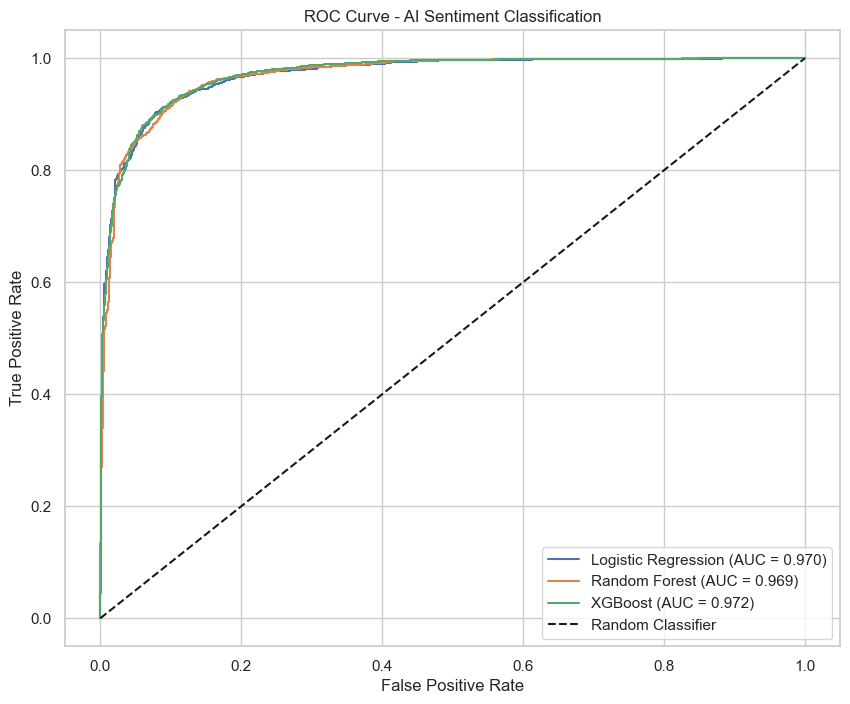

In [6]:
# Plot ROC Curve
plt.figure(figsize=(10, 8))
for name, metrics in results.items():
    fpr, tpr, _ = roc_curve(y_test, metrics['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {metrics['AUC-ROC']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - AI Sentiment Classification')
plt.legend(loc='lower right')
plt.show()

**Insights:**
- **Đường ROC (ROC Curve):** Cả ba mô hình đều có đường ROC uốn cong sát góc trên bên trái, thể hiện khả năng phân tách cực tốt giữa 2 nhóm lập trình viên (Favorable vs Unfavorable) trên tất cả các ngưỡng phân loại (thresholds).
- **XGBoost (AUC = 0.972):** Bao phủ diện tích lớn nhất, khẳng định đây là mô hình phân loại xuất sắc nhất cho bài toán này, bám sát là Logistic Regression (0.970) và Random Forest (0.969).

### **6. Feature Importance (Random Forest)**

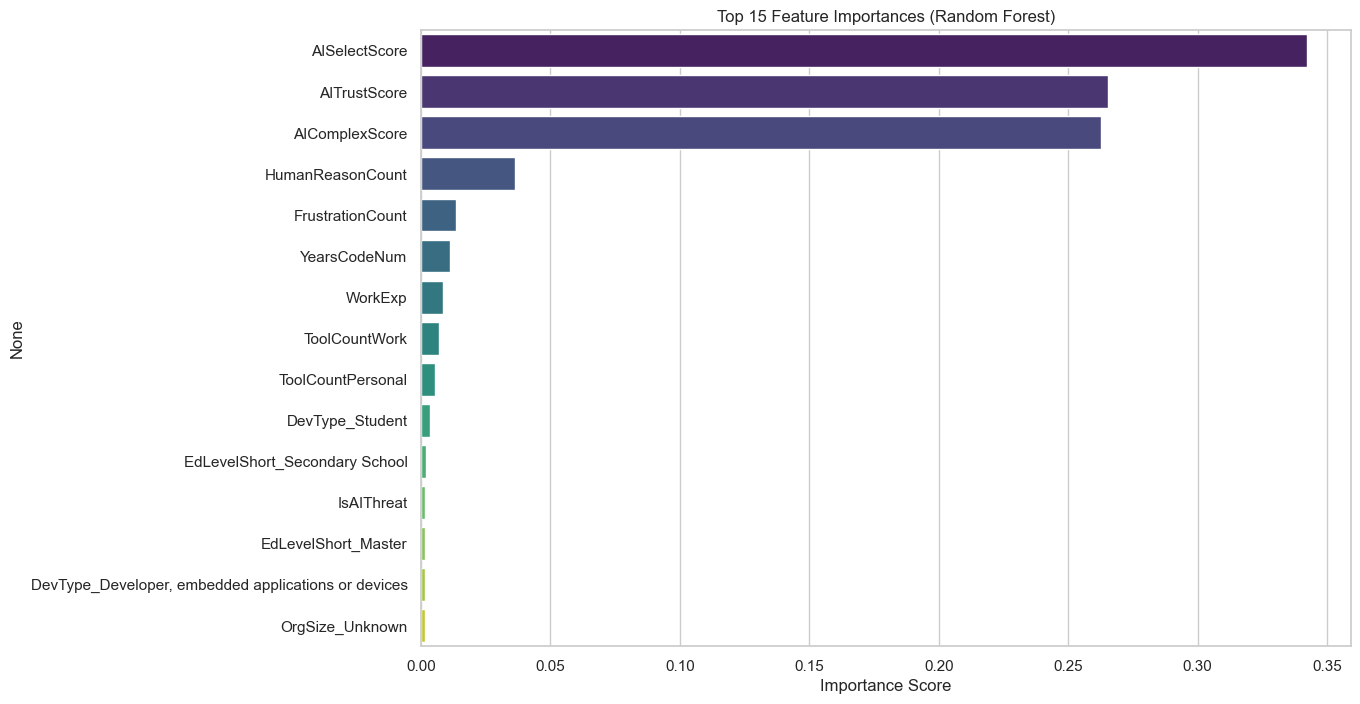

In [7]:
best_model = results['Random Forest']['Model']
importances = pd.Series(best_model.feature_importances_, index=X.columns)
top_features = importances.nlargest(15)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.show()

**Insights:**
- **AISelectScore (Tần suất sử dụng AI):** Áp đảo hoàn toàn với mức độ quan trọng trên **0.34**. Điều này cho thấy tần suất sử dụng thực tế quyết định trực tiếp đến thái độ của họ.
- **AITrustScore & AIComplexScore (Mức độ tin tưởng & Xử lý phức tạp):** Đứng thứ 2 và 3 với độ quan trọng ~**0.26**. Việc lập trình viên có tin vào độ chính xác và khả năng giải quyết các bài toán khó của AI hay không sẽ định hình thái độ Favorable của họ.
- **HumanReasonCount & FrustrationCount:** Các lý do mang tính chủ quan (human reasons) và sự bực dọc (frustrations) cũng đóng góp nhỏ vào quyết định phân loại, trong khi các yếu tố nhân khẩu học (Kinh nghiệm, Số tuổi nghề) gần như không ảnh hưởng.

### **7. SHAP Explainability**
Giải thích mô hình dự đoán (SHAP) để xem yếu tố nào ảnh hưởng đến việc Developer ủng hộ hay phản đối AI.

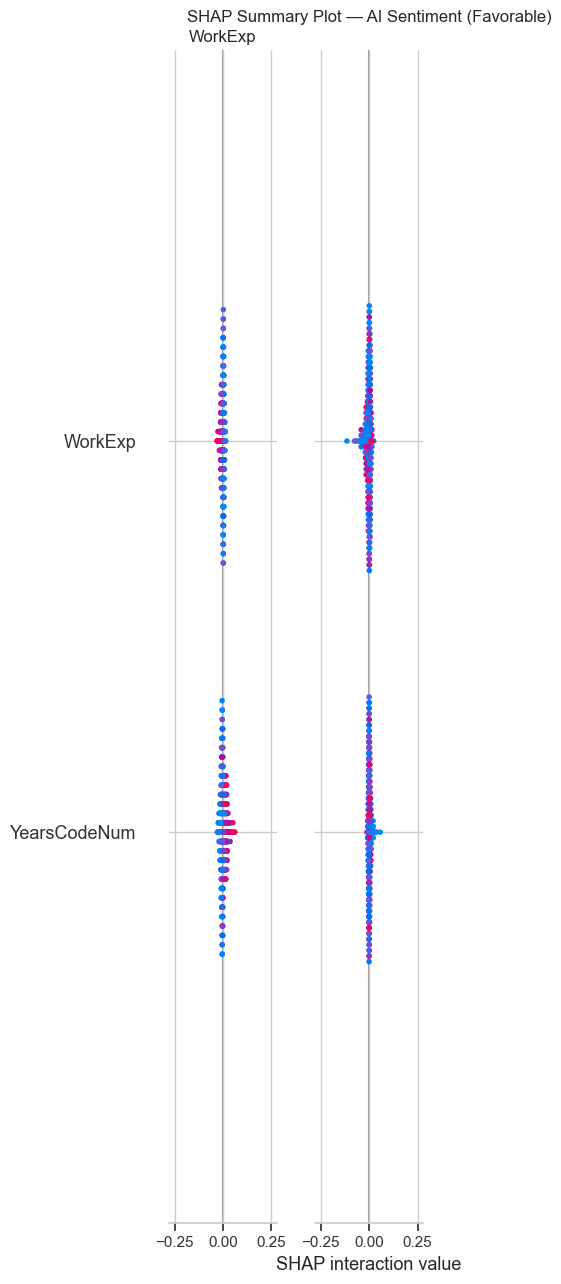

In [9]:
# Calculate SHAP values
explainer = shap.TreeExplainer(best_model)
X_sample = X_test.sample(500, random_state=42)
shap_values = explainer.shap_values(X_sample)

# Random Forest binary → shap_values là list [class_0, class_1]
# Lấy class 1 (Favorable) để vẽ
shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values

# Summary Plot
shap.summary_plot(shap_vals, X_sample, max_display=15, show=False)
plt.title('SHAP Summary Plot — AI Sentiment (Favorable)', pad=20)
plt.tight_layout()
plt.show()

**Insights:**
- **Biểu đồ SHAP Summary Plot:** Cung cấp cái nhìn đa chiều về cách mỗi tính năng tác động đến dự đoán. Các chấm đỏ (giá trị tính năng cao) của biến `AISelectScore`, `AITrustScore` và `AIComplexScore` đều nằm tụt về bên phải trục SHAP value (>0), tức là **tăng xác suất thuộc nhóm Favorable**.
- Ngược lại, các chấm xanh (giá trị thấp) của các biến này nằm về bên trái (<0), chứng tỏ nếu ít dùng AI hoặc không tin tưởng AI, mô hình sẽ phân loại họ vào nhóm Unfavorable.
- Đối với `FrustrationCount` (số lần gặp vấn đề bực mình) và `IsAIThreat` (xem AI là mối đe dọa), giá trị cao (màu đỏ) đẩy SHAP value về số âm, tức là làm tăng xác suất có thái độ Tiêu cực (Unfavorable).

### **Kết Luận**

1. **Hiệu suất Mô Hình:** Cả XGBoost và Random Forest đều đạt hiệu suất xuất sắc. **XGBoost** đạt Accuracy **91.32%**, F1-Score **0.9402** và AUC-ROC **0.9717**. **Random Forest** đạt Accuracy **90.57%**, F1-Score **0.9347** và AUC-ROC **0.9688**.
2. **Top Features:**
   - `AISelectScore` (Tần suất sử dụng AI): Đây là yếu tố quan trọng nhất. Càng dùng AI nhiều, họ càng có xu hướng "Favorable".
   - `AITrustScore` (Mức độ tin tưởng): Những người tin vào độ chính xác của AI dĩ nhiên sẽ ủng hộ AI.
   - `AIComplexScore`: Nhận định tốt về khả năng xử lý task phức tạp của AI tỷ lệ thuận với mức độ hài lòng.
   - `FrustrationCount`: Số lượng vấn đề bực mình khi dùng AI cũng là yếu tố quan trọng phân tách người dùng.
3. **Imbalance Handling:** Mặc dù tập dữ liệu lệch (Favorable chiếm **74.5%**), việc sử dụng class_weight / scale_pos_weight đã giúp mô hình có **Recall trên class 0 (Unfavorable)** rất tốt (đạt **0.90 - 0.92**), nhận diện chính xác lập trình viên ghét AI.